In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
# 打印 scanpy 版本，方便排查环境问题
print(f"Current Scanpy version: {sc.__version__}")

Current Scanpy version: 1.11.2


# 1. 数据读取

In [3]:
test_T1 = './T1_test_feature_bc_matrix/'
test_T2 = './T2_test_feature_bc_matrix/'

In [4]:
print(os.listdir(test_T1)) 
print(os.listdir(test_T2))

['matrix.mtx.gz', 'barcodes.tsv.gz', 'features.tsv.gz']
['matrix.mtx.gz', 'barcodes.tsv.gz', 'features.tsv.gz']


In [5]:
adata_T1 = sc.read_10x_mtx(test_T1,var_names='gene_ids',cache=True)
adata_T1

AnnData object with n_obs × n_vars = 1000 × 33437
    var: 'gene_symbols', 'feature_types'

In [6]:
adata_T2 = sc.read_10x_mtx(test_T2,var_names='gene_ids',cache=True)
adata_T2

AnnData object with n_obs × n_vars = 1000 × 33437
    var: 'gene_symbols', 'feature_types'

# 2. 双细胞检测与过滤

In [7]:
# 运行 Scrublet 算法进行双细胞评分 (使用默认自动阈值)
sc.pp.scrublet(adata_T1)
sc.pp.scrublet(adata_T2)

In [8]:
print(adata_T1)
print(adata_T2)

AnnData object with n_obs × n_vars = 1000 × 33437
    obs: 'doublet_score', 'predicted_doublet'
    var: 'gene_symbols', 'feature_types'
    uns: 'scrublet'
AnnData object with n_obs × n_vars = 1000 × 33437
    obs: 'doublet_score', 'predicted_doublet'
    var: 'gene_symbols', 'feature_types'
    uns: 'scrublet'


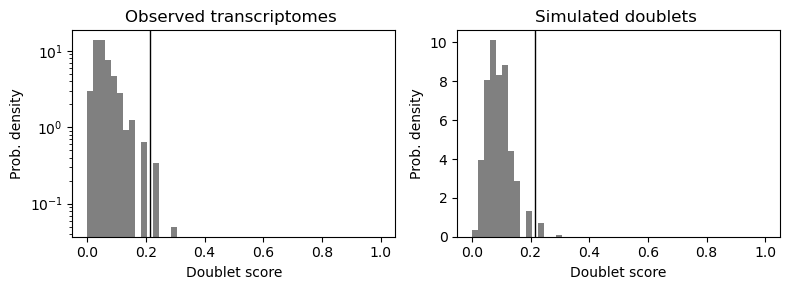

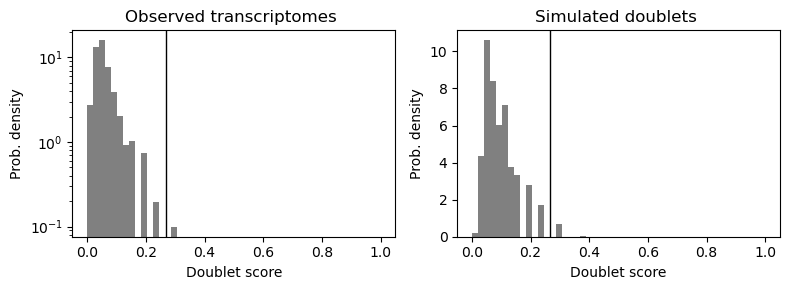

In [9]:
# 绘制双细胞得分分布直方图
sc.pl.scrublet_score_distribution(adata_T1)
sc.pl.scrublet_score_distribution(adata_T2)

In [10]:
# 自动检测得到的阈值过滤效果可能不佳。
# 我们根据观察上面的直方图，手动修改并设定过滤阈值 (例如设定为 0.2,实际阈值根据实际情况调整)
sc.pp.scrublet(adata_T1,threshold=0.2)
sc.pp.scrublet(adata_T2,threshold=0.16)

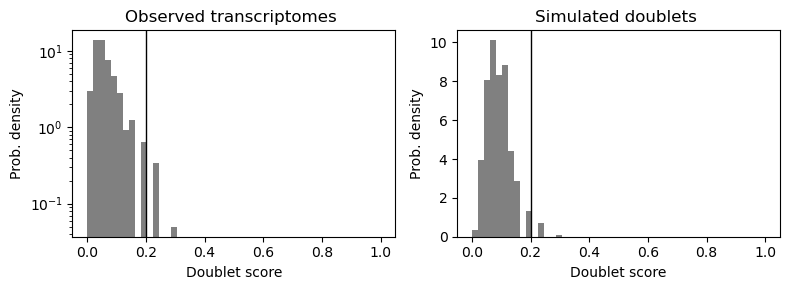

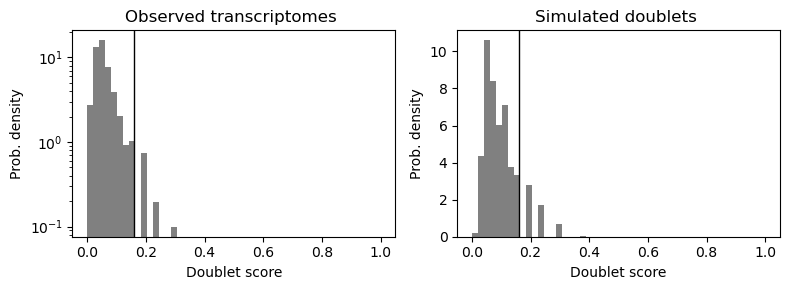

In [11]:
# 再次查看调整阈值后的分布
sc.pl.scrublet_score_distribution(adata_T1)
sc.pl.scrublet_score_distribution(adata_T2)

In [12]:
# 筛选出“非 doublet 细胞”，没有真正应用过滤。
print(adata_T1[~adata_T1.obs['predicted_doublet']])
print(adata_T2[~adata_T2.obs['predicted_doublet']])

View of AnnData object with n_obs × n_vars = 992 × 33437
    obs: 'doublet_score', 'predicted_doublet'
    var: 'gene_symbols', 'feature_types'
    uns: 'scrublet'
View of AnnData object with n_obs × n_vars = 958 × 33437
    obs: 'doublet_score', 'predicted_doublet'
    var: 'gene_symbols', 'feature_types'
    uns: 'scrublet'


In [13]:
# 执行过滤
adata_T1 = adata_T1[~adata_T1.obs['predicted_doublet']].copy()
adata_T2 = adata_T2[~adata_T2.obs['predicted_doublet']].copy()
print(adata_T1)
print(adata_T2)

AnnData object with n_obs × n_vars = 992 × 33437
    obs: 'doublet_score', 'predicted_doublet'
    var: 'gene_symbols', 'feature_types'
    uns: 'scrublet'
AnnData object with n_obs × n_vars = 958 × 33437
    obs: 'doublet_score', 'predicted_doublet'
    var: 'gene_symbols', 'feature_types'
    uns: 'scrublet'


# 3. 基础质控与过滤

In [14]:
# 过滤低质量细胞：要求每个细胞至少表达 100 个基因
# 过滤低表达基因：要求每个基因至少在 3 个细胞中表达
sc.pp.filter_cells(adata_T1, min_genes=100)
sc.pp.filter_genes(adata_T1, min_cells=3)
sc.pp.filter_cells(adata_T2, min_genes=100)
sc.pp.filter_genes(adata_T2, min_cells=3)

In [15]:
print("Data shape after basic QC (min_genes & min_cells):", adata_T1)
print("Data shape after basic QC (min_genes & min_cells):", adata_T2)

Data shape after basic QC (min_genes & min_cells): AnnData object with n_obs × n_vars = 992 × 16594
    obs: 'doublet_score', 'predicted_doublet', 'n_genes'
    var: 'gene_symbols', 'feature_types', 'n_cells'
    uns: 'scrublet'
Data shape after basic QC (min_genes & min_cells): AnnData object with n_obs × n_vars = 958 × 16814
    obs: 'doublet_score', 'predicted_doublet', 'n_genes'
    var: 'gene_symbols', 'feature_types', 'n_cells'
    uns: 'scrublet'


# 4. 导出结果文件

In [16]:
# 确保结果输出文件夹存在
output_dir = './Results'
os.makedirs(output_dir, exist_ok=True)

In [17]:
T1_bc_df = pd.DataFrame(adata_T1.obs.index,columns=['barcode'])
T1_bc_df.to_csv('./Results/T1_barcodes.csv',index=False)
len(T1_bc_df)

992

In [18]:
T2_bc_df = pd.DataFrame(adata_T2.obs.index,columns=['barcode'])
T2_bc_df.to_csv('./Results/T2_barcodes.csv',index=False)
len(T2_bc_df)

958